In [1]:
# =====================================
# Standard Libraries
# =====================================
import os
import random
import zipfile
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# =====================================
# Data Processing
# =====================================
import cv2
import numpy as np
import pandas as pd

# =====================================
# Visualization
# =====================================
import matplotlib.pyplot as plt

# =====================================
# Machine Learning
# =====================================
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight

# =====================================
# PyTorch
# =====================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =====================================
# TorchVision
# =====================================
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

# =====================================
# Utilities
# =====================================
from tqdm.auto import tqdm

In [2]:
# =====================================
# Device Configuration
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"Number of GPUs: {torch.cuda.device_count()}")

    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)

        print(f"\nGPU {i}")
        print(f"Name        : {props.name}")
        print(f"Memory      : {props.total_memory / 1024**3:.2f} GB")
        print(f"CUDA Version: {torch.version.cuda}")

else:
    print("No GPU detected. Running on CPU.")

Using device: cuda
Number of GPUs: 2

GPU 0
Name        : Tesla T4
Memory      : 14.56 GB
CUDA Version: 12.8

GPU 1
Name        : Tesla T4
Memory      : 14.56 GB
CUDA Version: 12.8


In [3]:
# =====================================
# Reproducibility
# =====================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(42)

In [4]:
# Install gdown (only once per Kaggle session)
!pip install -q gdown

In [5]:
# =====================================
# Download Dataset
# =====================================

DATASET_URL = "https://drive.google.com/uc?id=1KCKfyIGbQi8a7bIYta3LM8dFStxVzVX-"
DATASET_ZIP = "dataset.zip"

if not os.path.exists(DATASET_ZIP):
    print("Downloading dataset...")
    gdown.download(DATASET_URL, DATASET_ZIP, quiet=False)
else:
    print("Dataset already exists.")

Dataset already exists.


In [6]:
# =====================================
# Extract Dataset
# =====================================

DATASET_DIR = Path("/kaggle/working/Shop DataSet")

if not DATASET_DIR.exists():

    print("Extracting dataset...")

    with zipfile.ZipFile(DATASET_ZIP, "r") as zip_ref:
        zip_ref.extractall("/kaggle/working")

    print("Dataset extracted successfully.")

else:
    print("Dataset already extracted.")

Dataset already extracted.


In [7]:
# =====================================
# Check Duplicate Video Content (MD5)
# =====================================

import hashlib
from pathlib import Path


def calculate_md5(file_path, chunk_size=8192):
    """
    Calculate MD5 hash of a file.
    Reading in chunks avoids loading large videos into memory.
    """
    md5 = hashlib.md5()

    with open(file_path, "rb") as f:
        while chunk := f.read(chunk_size):
            md5.update(chunk)

    return md5.hexdigest()


shop_video = Path("/kaggle/working/Shop DataSet/shop lifters/videppppsss_44.mp4")
nonshop_video = Path("/kaggle/working/Shop DataSet/non shop lifters/videppppsss_44.mp4")

assert shop_video.exists(), f"{shop_video} not found."
assert nonshop_video.exists(), f"{nonshop_video} not found."

shop_hash = calculate_md5(shop_video)
nonshop_hash = calculate_md5(nonshop_video)

print(f"Shoplifting Video MD5     : {shop_hash}")
print(f"Non-Shoplifting Video MD5 : {nonshop_hash}")

if shop_hash == nonshop_hash:
    print("\n⚠️ Duplicate video content detected!")
else:
    print("\n✅ Different video contents (same filename only).")

Shoplifting Video MD5     : 908e68a57eeb580d5f7fd0a3d0f9f71a
Non-Shoplifting Video MD5 : 1ef46e3802a84ceba49a509c2398fab5

✅ Different video contents (same filename only).


In [8]:
# =====================================
# Inspect Dataset Structure
# =====================================

DATASET_DIR = Path("/kaggle/working/Shop DataSet")

for class_dir in sorted(DATASET_DIR.iterdir()):
    if class_dir.is_dir():
        videos = list(class_dir.glob("*.mp4"))

        print(f"{class_dir.name}")
        print(f"Number of videos : {len(videos)}")

        if videos:
            print(f"Sample video     : {videos[0].name}")

        print("-" * 40)

non shop lifters
Number of videos : 531
Sample video     : videppppsss_44.mp4
----------------------------------------
shop lifters
Number of videos : 324
Sample video     : videyyyyyynnnnnnzzzzzyyyss_9.mp4
----------------------------------------


In [9]:
# =====================================
# Create DataFrame
# =====================================

DATASET_PATH = Path("/kaggle/working/Shop DataSet")

classes = {
    "non shop lifters": 0,
    "shop lifters": 1
}

data = []

for class_name, label in classes.items():

    folder = DATASET_PATH / class_name

    for video_path in sorted(folder.glob("*.mp4")):

        data.append({
            "video_path": str(video_path),
            "label": label,
            "class_name": class_name
        })

df = pd.DataFrame(data)

# =====================================
# Dataset Summary
# =====================================

print(f"Total Videos : {len(df)}\n")

print("Class Distribution")
print(df["class_name"].value_counts())

print("\nMissing Values")
print(df.isnull().sum())

print(f"\nDuplicate Paths : {df['video_path'].duplicated().sum()}")

display(df.head())

Total Videos : 855

Class Distribution
class_name
non shop lifters    531
shop lifters        324
Name: count, dtype: int64

Missing Values
video_path    0
label         0
class_name    0
dtype: int64

Duplicate Paths : 0


,video_path,label,class_name
0,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
1,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
2,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
3,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters
4,/kaggle/working/Shop DataSet/non shop lifters/...,0,non shop lifters


In [10]:
# =====================================
# Analyze Video Lengths
# =====================================

frame_counts = []

for video_path in tqdm(df["video_path"], desc="Analyzing Videos"):

    cap = cv2.VideoCapture(video_path)

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_counts.append(frame_count)

    cap.release()

df["num_frames"] = frame_counts

print(f"Minimum Frames : {df['num_frames'].min()}")
print(f"Maximum Frames : {df['num_frames'].max()}")
print(f"Average Frames : {df['num_frames'].mean():.2f}")
print(f"Median Frames  : {df['num_frames'].median():.2f}")

Analyzing Videos:   0%|          | 0/855 [00:00<?, ?it/s]

Minimum Frames : 75
Maximum Frames : 1850
Average Frames : 331.42
Median Frames  : 325.00


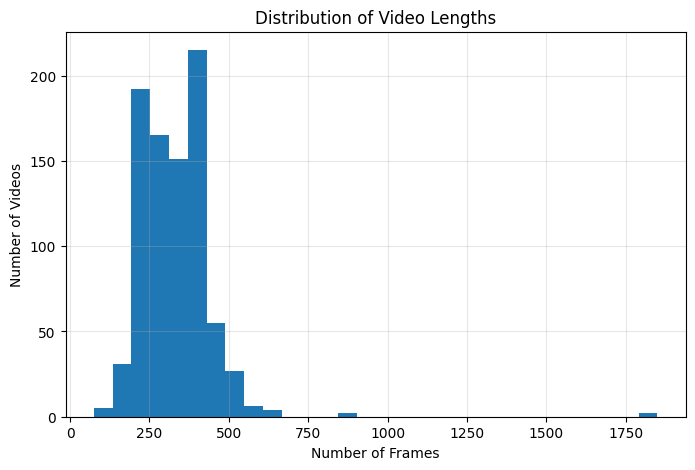

In [11]:
# =====================================
# Distribution of Video Lengths
# =====================================

plt.figure(figsize=(8, 5))

plt.hist(df["num_frames"], bins=30)

plt.title("Distribution of Video Lengths")
plt.xlabel("Number of Frames")
plt.ylabel("Number of Videos")

plt.grid(alpha=0.3)

plt.show()

In [12]:
# =====================================
# Dataset Overview
# =====================================

print(f"Dataset Shape: {df.shape}")

print("\nClass Distribution:")
print(df["class_name"].value_counts())

print("\nClass Percentage:")
print((df["class_name"].value_counts(normalize=True) * 100).round(2))

Dataset Shape: (855, 4)

Class Distribution:
class_name
non shop lifters    531
shop lifters        324
Name: count, dtype: int64

Class Percentage:
class_name
non shop lifters    62.11
shop lifters        37.89
Name: proportion, dtype: float64


In [13]:
# =====================================
# Configuration
# =====================================

SEED = 42

# Dataset
IMAGE_SIZE = 112
NUM_FRAMES = 32
NUM_CLASSES = 2

# DataLoader
BATCH_SIZE = 8
NUM_WORKERS = 2
PIN_MEMORY = torch.cuda.is_available()

# Training
EPOCHS = 20
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-5

# Scheduler
LR_FACTOR = 0.5
LR_PATIENCE = 3

In [14]:
# =====================================
# Train / Validation / Test Split
# =====================================

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

# Reset indices
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train Set      : {len(train_df)}")
print(f"Validation Set : {len(val_df)}")
print(f"Test Set       : {len(test_df)}")

print("\nTrain Distribution")
print(train_df["class_name"].value_counts(normalize=True).round(3))

print("\nValidation Distribution")
print(val_df["class_name"].value_counts(normalize=True).round(3))

print("\nTest Distribution")
print(test_df["class_name"].value_counts(normalize=True).round(3))

Train Set      : 598
Validation Set : 128
Test Set       : 129

Train Distribution
class_name
non shop lifters    0.62
shop lifters        0.38
Name: proportion, dtype: float64

Validation Distribution
class_name
non shop lifters    0.625
shop lifters        0.375
Name: proportion, dtype: float64

Test Distribution
class_name
non shop lifters    0.62
shop lifters        0.38
Name: proportion, dtype: float64


In [15]:
def load_video(
    video_path,
    num_frames=NUM_FRAMES,
    img_size=IMAGE_SIZE
):
    # =====================================
    # Load and Sample Video Frames
    # =====================================

    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Return empty frames if the video is corrupted or empty
    if total_frames <= 0:
        cap.release()
        return np.zeros(
            (num_frames, img_size, img_size, 3),
            dtype=np.float32
        )

    # Uniformly sample frames across the entire video
    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames,
        dtype=np.int32
    )

    required_frames = set(frame_indices.tolist())
    collected_frames = {}

    current_idx = 0

    # Read frames sequentially for reliable frame extraction
    while True:

        success, frame = cap.read()

        if not success:
            break

        if current_idx in required_frames:

            if frame is None:
                current_idx += 1
                continue

            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # Resize frame
            frame = cv2.resize(frame, (img_size, img_size))

            # Normalize pixel values to [0, 1]
            frame = frame.astype(np.float32) / 255.0

            collected_frames[current_idx] = frame

        current_idx += 1

    cap.release()

    sampled_frames = []
    last_valid_frame = None

    # Fill missing frames using the last valid frame
    for idx in frame_indices:

        if idx in collected_frames:

            last_valid_frame = collected_frames[idx]
            sampled_frames.append(last_valid_frame)

        elif last_valid_frame is not None:

            sampled_frames.append(last_valid_frame)

        else:

            sampled_frames.append(
                np.zeros(
                    (img_size, img_size, 3),
                    dtype=np.float32
                )
            )

    sampled_frames = np.stack(sampled_frames).astype(np.float32)

    return sampled_frames

In [16]:
# def augment_video(
#     frames,
#     img_size=IMAGE_SIZE
# ):
#     # =====================================
#     # Video Data Augmentation
#     # =====================================

#     # Apply the same random transformation to all frames
#     do_flip = random.random() > 0.5

#     i, j, h, w = transforms.RandomResizedCrop.get_params(
#         torch.from_numpy(frames[0]).permute(2, 0, 1),
#         scale=(0.8, 1.0),
#         ratio=(0.9, 1.1)
#     )

#     brightness = random.uniform(0.8, 1.2)
#     contrast = random.uniform(0.8, 1.2)
#     saturation = random.uniform(0.8, 1.2)

#     augmented_frames = []

#     for frame in frames:

#         frame = torch.from_numpy(frame).permute(2, 0, 1)

#         # Horizontal Flip
#         if do_flip:
#             frame = TF.hflip(frame)

#         # Random Crop + Resize
#         frame = TF.resized_crop(
#             frame,
#             i,
#             j,
#             h,
#             w,
#             size=(img_size, img_size)
#         )

#         # Color Augmentation
#         frame = TF.adjust_brightness(frame, brightness)
#         frame = TF.adjust_contrast(frame, contrast)
#         frame = TF.adjust_saturation(frame, saturation)

#         augmented_frames.append(
#             frame.permute(1, 2, 0).numpy()
#         )

#     return np.stack(augmented_frames).astype(np.float32)

In [17]:
def augment_video(frames, img_size=IMAGE_SIZE):
    return frames

In [18]:
class VideoDataset(Dataset):

    def __init__(
        self,
        dataframe,
        num_frames=NUM_FRAMES,
        img_size=IMAGE_SIZE,
        train=True
    ):
        # =====================================
        # Initialize Dataset
        # =====================================

        self.dataframe = dataframe.reset_index(drop=True)
        self.num_frames = num_frames
        self.img_size = img_size
        self.train = train

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        # Load video path and label
        video_path = self.dataframe.iloc[idx]["video_path"]
        label = self.dataframe.iloc[idx]["label"]

        # Load sampled video frames
        frames = load_video(
            video_path,
            self.num_frames,
            self.img_size
        )

        # Apply data augmentation during training only
        if self.train:
            frames = augment_video(
                frames,
                self.img_size
            )

        # Convert from (T, H, W, C) to (C, T, H, W)
        frames = np.transpose(frames, (3, 0, 1, 2))

        # Convert to PyTorch tensors
        frames = torch.from_numpy(frames).float()
        label = torch.tensor(label, dtype=torch.long)

        return frames, label

In [19]:
# =====================================
# Create Datasets
# =====================================

train_dataset = VideoDataset(
    train_df,
    num_frames=NUM_FRAMES,
    img_size=IMAGE_SIZE,
    train=True
)

val_dataset = VideoDataset(
    val_df,
    num_frames=NUM_FRAMES,
    img_size=IMAGE_SIZE,
    train=False
)

test_dataset = VideoDataset(
    test_df,
    num_frames=NUM_FRAMES,
    img_size=IMAGE_SIZE,
    train=False
)

In [20]:
from torch.utils.data import WeightedRandomSampler

class_counts = train_df["label"].value_counts().sort_index()

sample_weights = train_df["label"].map(
    lambda lbl: 1.0 / class_counts[lbl]
).values

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [21]:
# =====================================
# Create DataLoaders
# =====================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    drop_last=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=True,
    drop_last=False
)

In [22]:
# =====================================
# Check DataLoader Output
# =====================================

videos, labels = next(iter(train_loader))

print(f"Videos Shape : {videos.shape}")
print(f"Labels Shape : {labels.shape}")
print(f"Labels       : {labels}")
print(f"Data Type    : {videos.dtype}")

Videos Shape : torch.Size([8, 3, 32, 112, 112])
Labels Shape : torch.Size([8])
Labels       : tensor([0, 1, 0, 0, 0, 1, 1, 1])
Data Type    : torch.float32


In [23]:
class CNN3D(nn.Module):

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        # =====================================
        # Feature Extractor
        # =====================================

        self.features = nn.Sequential(

            # Block 1
            nn.Conv3d(3, 32, kernel_size=3, padding=1),
            nn.GroupNorm(8, 32),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),

            # Block 2
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=(1, 2, 2)),

            # Block 3
            nn.Conv3d(64, 128, kernel_size=3, padding=1),
            nn.GroupNorm(8, 128),
            nn.ReLU(inplace=True),
            nn.MaxPool3d(kernel_size=2),

            # Block 4
            nn.Conv3d(128, 256, kernel_size=3, padding=1),
            nn.GroupNorm(8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout3d(0.2),

            # Global Pooling
            nn.AdaptiveAvgPool3d((1, 1, 1))
        )

        # =====================================
        # Classifier
        # =====================================

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),

            nn.Linear(128, num_classes)
        )

        # =====================================
        # Initialize Weights
        # =====================================

        self._initialize_weights()

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

    def _initialize_weights(self):
        # Initialize Conv3D and Linear layers using Kaiming Initialization

        for m in self.modules():

            if isinstance(m, nn.Conv3d):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

            elif isinstance(m, nn.Linear):

                nn.init.kaiming_normal_(
                    m.weight,
                    nonlinearity="relu"
                )

                nn.init.zeros_(m.bias)

In [24]:
# =====================================
# Initialize Model
# =====================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN3D(num_classes=NUM_CLASSES).to(device)

# Test model with a dummy input
dummy_input = torch.randn(
    BATCH_SIZE,
    3,
    NUM_FRAMES,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)

output = model(dummy_input)

print(f"Output Shape : {output.shape}")

Output Shape : torch.Size([8, 2])


In [25]:
# =====================================
# Loss Function, Optimizer and Scheduler
# =====================================

import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32,
    device=device
)

print("Class Weights:", class_weights.cpu().numpy())

# Loss Function
criterion = nn.CrossEntropyLoss()


# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE
)

Class Weights: [0.8059299 1.3171806]


In [26]:
# =====================================
# Training History
# =====================================

train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [27]:
from sklearn.metrics import precision_score, recall_score, f1_score


best_f1 = 0

for epoch in range(EPOCHS):

    ##########################
    # Training
    ##########################

    model.train()

    train_loss = 0
    train_correct = 0
    train_total = 0

    for videos, labels in tqdm(train_loader):

        videos = videos.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(videos)

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()

        train_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()


    train_loss /= len(train_loader)
    train_accuracy = train_correct / train_total


    ##########################
    # Validation
    ##########################

    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for videos, labels in val_loader:

            videos = videos.to(device)
            labels = labels.to(device)

            outputs = model(videos)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    val_loss /= len(val_loader)
    val_accuracy = val_correct / val_total


    # Metrics for imbalance problem
    precision = precision_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )


    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

    print(
        f"Precision: {precision:.4f} | "
        f"Recall: {recall:.4f} | "
        f"F1: {f1:.4f}"
    )


    ##########################
    # Save Best Model
    ##########################

    if f1 > best_f1:

        best_f1 = f1

        torch.save(
            model.state_dict(),
            "best_3dcnn_model.pth"
        )

        print("Saved Best Model ✅")


    ##########################
    # Scheduler
    ##########################

    scheduler.step(val_loss)


    ##########################
    # History
    ##########################

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_accuracy)
    val_accs.append(val_accuracy)

  0%|          | 0/74 [00:04<?, ?it/s]

Epoch 1/20
Train Loss: 0.8693 | Train Acc: 0.5034
Val Loss: 0.6615 | Val Acc: 0.6250
Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


  0%|          | 0/74 [00:00<?, ?it/s]

Epoch 2/20
Train Loss: 0.7530 | Train Acc: 0.5000
Val Loss: 0.6726 | Val Acc: 0.6250
Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


  0%|          | 0/74 [00:00<?, ?it/s]

...

Epoch 18/20
Train Loss: 0.6948 | Train Acc: 0.4865
Val Loss: 0.6820 | Val Acc: 0.6250
Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


  0%|          | 0/74 [00:00<?, ?it/s]

Epoch 19/20
Train Loss: 0.6990 | Train Acc: 0.5017
Val Loss: 0.6806 | Val Acc: 0.6250
Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


  0%|          | 0/74 [00:00<?, ?it/s]

Epoch 20/20
Train Loss: 0.6972 | Train Acc: 0.5135
Val Loss: 0.6805 | Val Acc: 0.6250
Precision: 0.0000 | Recall: 0.0000 | F1: 0.0000


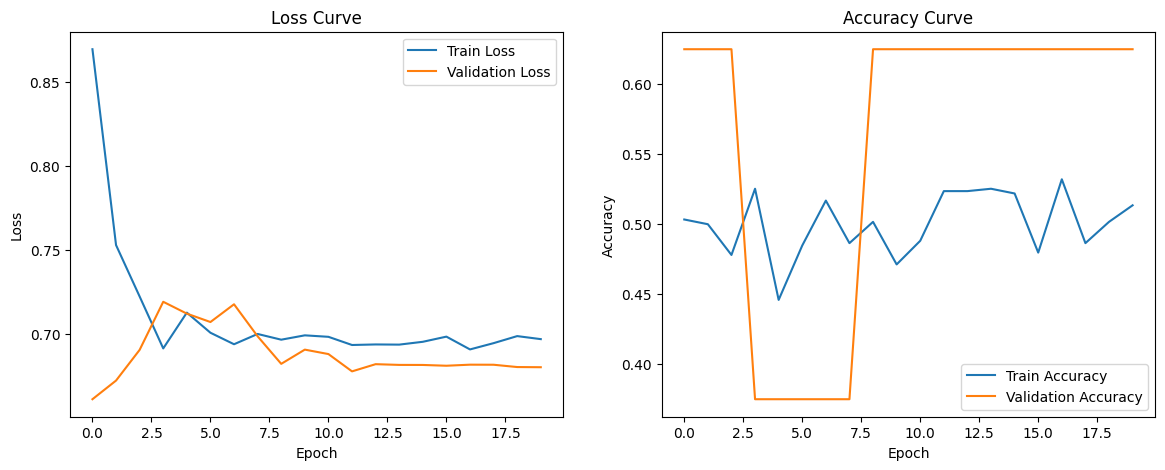

In [28]:
# =====================================
# Plot Training History
# Visualize Loss and Accuracy curves
# =====================================

import matplotlib.pyplot as plt


# Create figure containing two plots
plt.figure(figsize=(14, 5))


# =====================================
# Loss Curve
# Compare training loss vs validation loss
# =====================================

plt.subplot(1, 2, 1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()


# =====================================
# Accuracy Curve
# Compare training accuracy vs validation accuracy
# =====================================

plt.subplot(1, 2, 2)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()


# Display plots
plt.show()

Test Accuracy : 0.6202
Precision     : 0.0000
Recall        : 0.0000
F1-score      : 0.0000

Classification Report:

                 precision    recall  f1-score   support

Non-Shoplifting       0.62      1.00      0.77        80
    Shoplifting       0.00      0.00      0.00        49

       accuracy                           0.62       129
      macro avg       0.31      0.50      0.38       129
   weighted avg       0.38      0.62      0.47       129



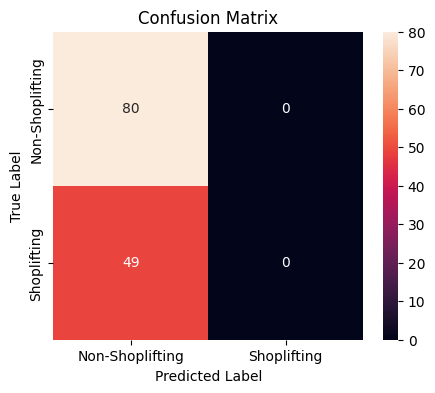

In [29]:
# =====================================
# Model Evaluation on Test Set
# Calculate Accuracy, Precision, Recall, F1-score
# and analyze class imbalance effect
# =====================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt


# Set model to evaluation mode
model.eval()


# Lists to store predictions and true labels
all_labels = []
all_preds = []


# Disable gradient calculation during evaluation
with torch.no_grad():

    # Iterate through test batches
    for videos, labels in test_loader:

        # Move data to GPU/CPU device
        videos = videos.to(device)
        labels = labels.to(device)


        # Forward pass
        outputs = model(videos)


        # Get predicted class
        _, predicted = torch.max(outputs, 1)


        # Store predictions and labels
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(predicted.cpu().numpy())



# =====================================
# Calculate Evaluation Metrics
# =====================================

test_accuracy = accuracy_score(
    all_labels,
    all_preds
)


test_precision = precision_score(
    all_labels,
    all_preds,
    zero_division=0
)


test_recall = recall_score(
    all_labels,
    all_preds,
    zero_division=0
)


test_f1 = f1_score(
    all_labels,
    all_preds,
    zero_division=0
)



# Print main metrics
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1-score      : {test_f1:.4f}")



# =====================================
# Detailed Classification Report
# Shows performance for each class
# =====================================

print("\nClassification Report:\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=[
            "Non-Shoplifting",
            "Shoplifting"
        ],
        zero_division=0
    )
)



# =====================================
# Confusion Matrix
# Analyze model bias between classes
# =====================================

cm = confusion_matrix(
    all_labels,
    all_preds
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Non-Shoplifting",
        "Shoplifting"
    ],
    yticklabels=[
        "Non-Shoplifting",
        "Shoplifting"
    ]
)


plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix")

plt.show()